In [249]:
import gymnasium as gym
from collections import namedtuple
import numpy as np
from matplotlib import pyplot as plt
import math

In [427]:
def visualize_options_policies(env, policies, policy_titles, symbol_map = None):
    """
    Visualize the policies of the options in a grid format.
    """

    num_policies = len(policies)

    ncols = 3 if num_policies > 4 else 2
    nrows = math.ceil(num_policies / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 6))


    for idx, (policy, title) in enumerate(zip(policies, policy_titles)):
        ax = axes[idx // ncols][idx % ncols]
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.invert_yaxis()
        ax.set_aspect('equal')

        # Heatmap
        im = ax.imshow(policy, cmap='Pastel1')

        # Draw arrows centered in grid
        for i in range(5):
            for j in range(5):
                action = policy[i, j]
                symbol = symbol_map[action]
                ax.text(j, i, symbol, fontsize=12, ha='center', va='center')
            
    plt.tight_layout()
    plt.show()


In [428]:
class Option:
    def __init__(self, name, policy, termination, initiaion):
        self.name = name
        self.policy = policy
        self.termination = termination
        self.initiaion = initiaion


In [429]:
# Initialize the options with their respective policies and termination conditions
# We are hardcoding the option policies - we will not be learning them

go_to_g = np.array([[0,0,2,2,0],
                    [0,0,2,2,1],
                    [2,2,2,2,1],
                    [1,1,1,1,1],
                    [1,1,1,1,1]])


go_to_b = np.array([[0,0,0,0,0],
                    [0,0,0,0,0],
                    [2,2,2,0,3],
                    [1,1,1,0,3],
                    [1,1,1,0,3]])

go_to_y = np.array([[0,3,0,0,0],
                    [0,3,0,0,0],
                    [0,3,3,3,3],
                    [0,1,1,1,1],
                    [0,1,1,1,1]])

go_to_r = np.array([[0,3,0,0,0],
                    [1,1,0,0,0],
                    [1,1,3,3,3],
                    [1,1,1,1,1],
                    [1,1,1,1,1]])

predefined_policies = {
    'go_to_green': go_to_g,
    'go_to_blue': go_to_b,
    'go_to_yellow': go_to_y,
    'go_to_red': go_to_r
}


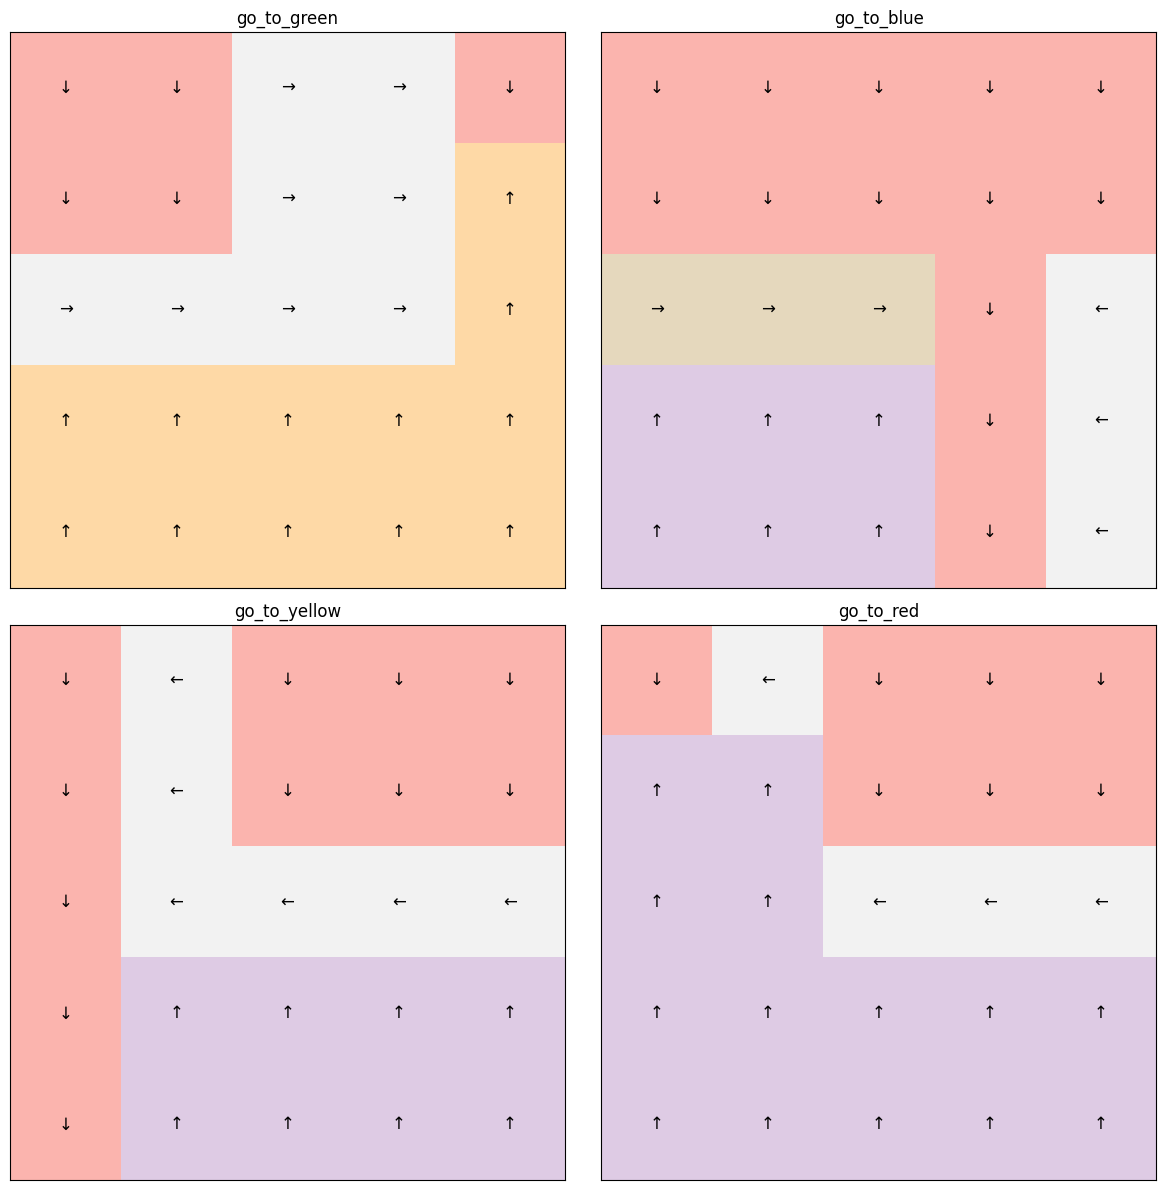

In [430]:
markers = {
    0: '↓',
    1: '↑',
    2: '→',
    3: '←',
    4: "Pickup",
    5: "Drop"
}

visualize_options_policies(None, predefined_policies.values(), predefined_policies.keys(), markers)

In [565]:
env = gym.make("Taxi-v3", render_mode = "rgb_array")
position = env.unwrapped.locs
position

[(0, 0), (0, 4), (4, 0), (4, 3)]

In [566]:
def decode_state(state):
    taxi_row, taxi_col, pass_loc, dest_loc = env.unwrapped.decode(state)
    return taxi_row, taxi_col, pass_loc, dest_loc

In [567]:
class Option:
    def __init__(self, initiation_set, policy, termination_condition, name = None ):
        
        self.initiation_set = initiation_set
        self.policy = policy
        self.termination_condition = termination_condition
        self.name = name if name else "UnnamedOption"

    def can_initiate(self, state):
        return self.initiation_set(state)
    
    def select_action(self, state):
        return self.policy(state)
    
    def should_terminate(self, state):
        return self.termination_condition(state)
    
    def __repr__(self):
        return f"Option: {self.name}"

In [581]:
action_map = {
    0: "South",
    1: "North",
    2: "East",
    3: "West",
    4: "Pickup",
    5: "Dropoff"
}

#defining the primitive actions as options

possible_options = [
    Option(
        initiation_set=lambda state: True,
        policy  = lambda state, act = action: act,
        termination_condition=lambda state: True,
        name = f"{action_map[action]}"
    )
    for action in range(env.action_space.n)
]

# Adding the predefined options with hardcoded policies
target_loc = {
    'go_to_green': (0,4),
    'go_to_blue': (4,3),
    'go_to_yellow': (4,0),
    'go_to_red': (0,0)
}

for option, policy in predefined_policies.items():
    possible_options.append(
        Option(
            initiation_set=lambda state, target = target_loc[option] : decode_state(state)[:2] != target,
            policy  = lambda state: policy[decode_state(state)[0], decode_state(state)[1]],
            termination_condition=lambda state, target = target_loc[option]: decode_state(state)[:2] == target,
            name = option
        )
    )

In [ ]:
# possible_options = possible_options[4:]
# possible_options

[Option: Pickup,
 Option: Dropoff,
 Option: go_to_green,
 Option: go_to_blue,
 Option: go_to_yellow,
 Option: go_to_red]

In [570]:
state = env.reset()[0]

In [582]:
decode_state(state)[:2] == target_loc['go_to_green']

False

In [583]:
from tqdm import tqdm
num_episodes = 5000
epsilon = 1
epsilon_decay = 0.99
gamma = 0.99
learning_rate = 0.8

# num_runs = 5
# reward_over_runs = []
# q_values_over_runs = []
# for run in tqdm(range(num_runs)):
q_values = np.zeros((env.observation_space.n, len(possible_options)))

rewards = []
for episode in tqdm(range(num_episodes)):
    state, _ = env.reset()
    type(state)
    done = False
    episode_reward = 0
    while not done:
        feasible_options = [ i for i, o in enumerate(possible_options) if o.can_initiate(state)]
        if np.random.rand() < epsilon:
            option = np.random.choice(feasible_options)
        else:
            option = np.argmax(q_values[state])

        r_bar = 0
        initial_state = state
        option_terminated = False
        while not option_terminated:
            action = possible_options[option].select_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            r_bar = r_bar * gamma + reward
            done = terminated | truncated
            option_terminated = possible_options[option].should_terminate(next_state) | done
            state = next_state
        epsilon = max(0.01, epsilon * epsilon_decay)
        q_values[initial_state, option] += learning_rate * (r_bar + gamma * np.max(q_values[next_state]) - q_values[initial_state, option])
        episode_reward += r_bar
    rewards.append(episode_reward)
    # reward_over_runs.append(rewards)
    # q_values_over_runs.append(q_values)
                


100%|██████████| 5000/5000 [00:25<00:00, 199.81it/s]


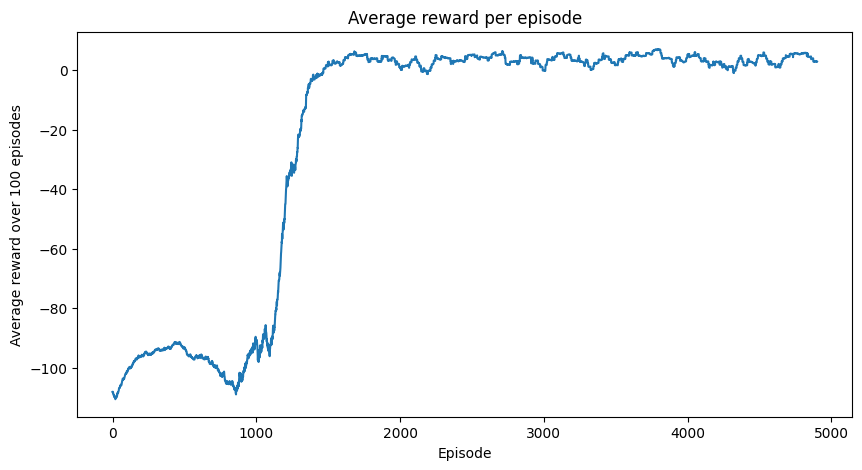

In [584]:
# reward_over_runs = np.array(reward_over_runs)
plt.figure(figsize=(10, 5))
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'))
plt.title("Average reward per episode")
plt.xlabel("Episode")
plt.ylabel("Average reward over 100 episodes")
plt.show()

In [440]:
# from IPython.display import Video, display
# from gymnasium.wrappers import RecordVideo
# from pathlib import Path
# import numpy as np
# import gymnasium as gym
# import os

# # Create video folder
# video_path = Path("videos")
# video_path.mkdir(exist_ok=True, parents=True)

# # Create a fresh environment with video recording
# env = gym.make("Taxi-v3", render_mode="rgb_array")  # important for video
# env = RecordVideo(env, video_folder=str(video_path), episode_trigger=lambda x: x%100 == 0, name_prefix="option_learning")

# # Reset the environment
# state, _ = env.reset()
# done = False

# # Run the episode
# while not done:
#     # Choose the best option for the current state
#     option_idx = np.argmax(q_values[state])
#     option = possible_options[option_idx]
    
#     # Run the selected option until termination
#     option_terminated = False
#     while not option_terminated:
#         action = option.select_action(state)
#         next_state, reward, terminated, truncated, _ = env.step(action)
#         state = next_state
#         done = terminated or truncated
#         option_terminated = option.should_terminate(state) or done

# # Close the environment and show the video
# env.close()

# # Find the saved video file and display it
# video_files = list(video_path.glob("option_learning*.mp4"))
# if video_files:
#     display(Video(str(video_files[-1])))  # Show the latest video
# else:
#     print("No video was recorded.")


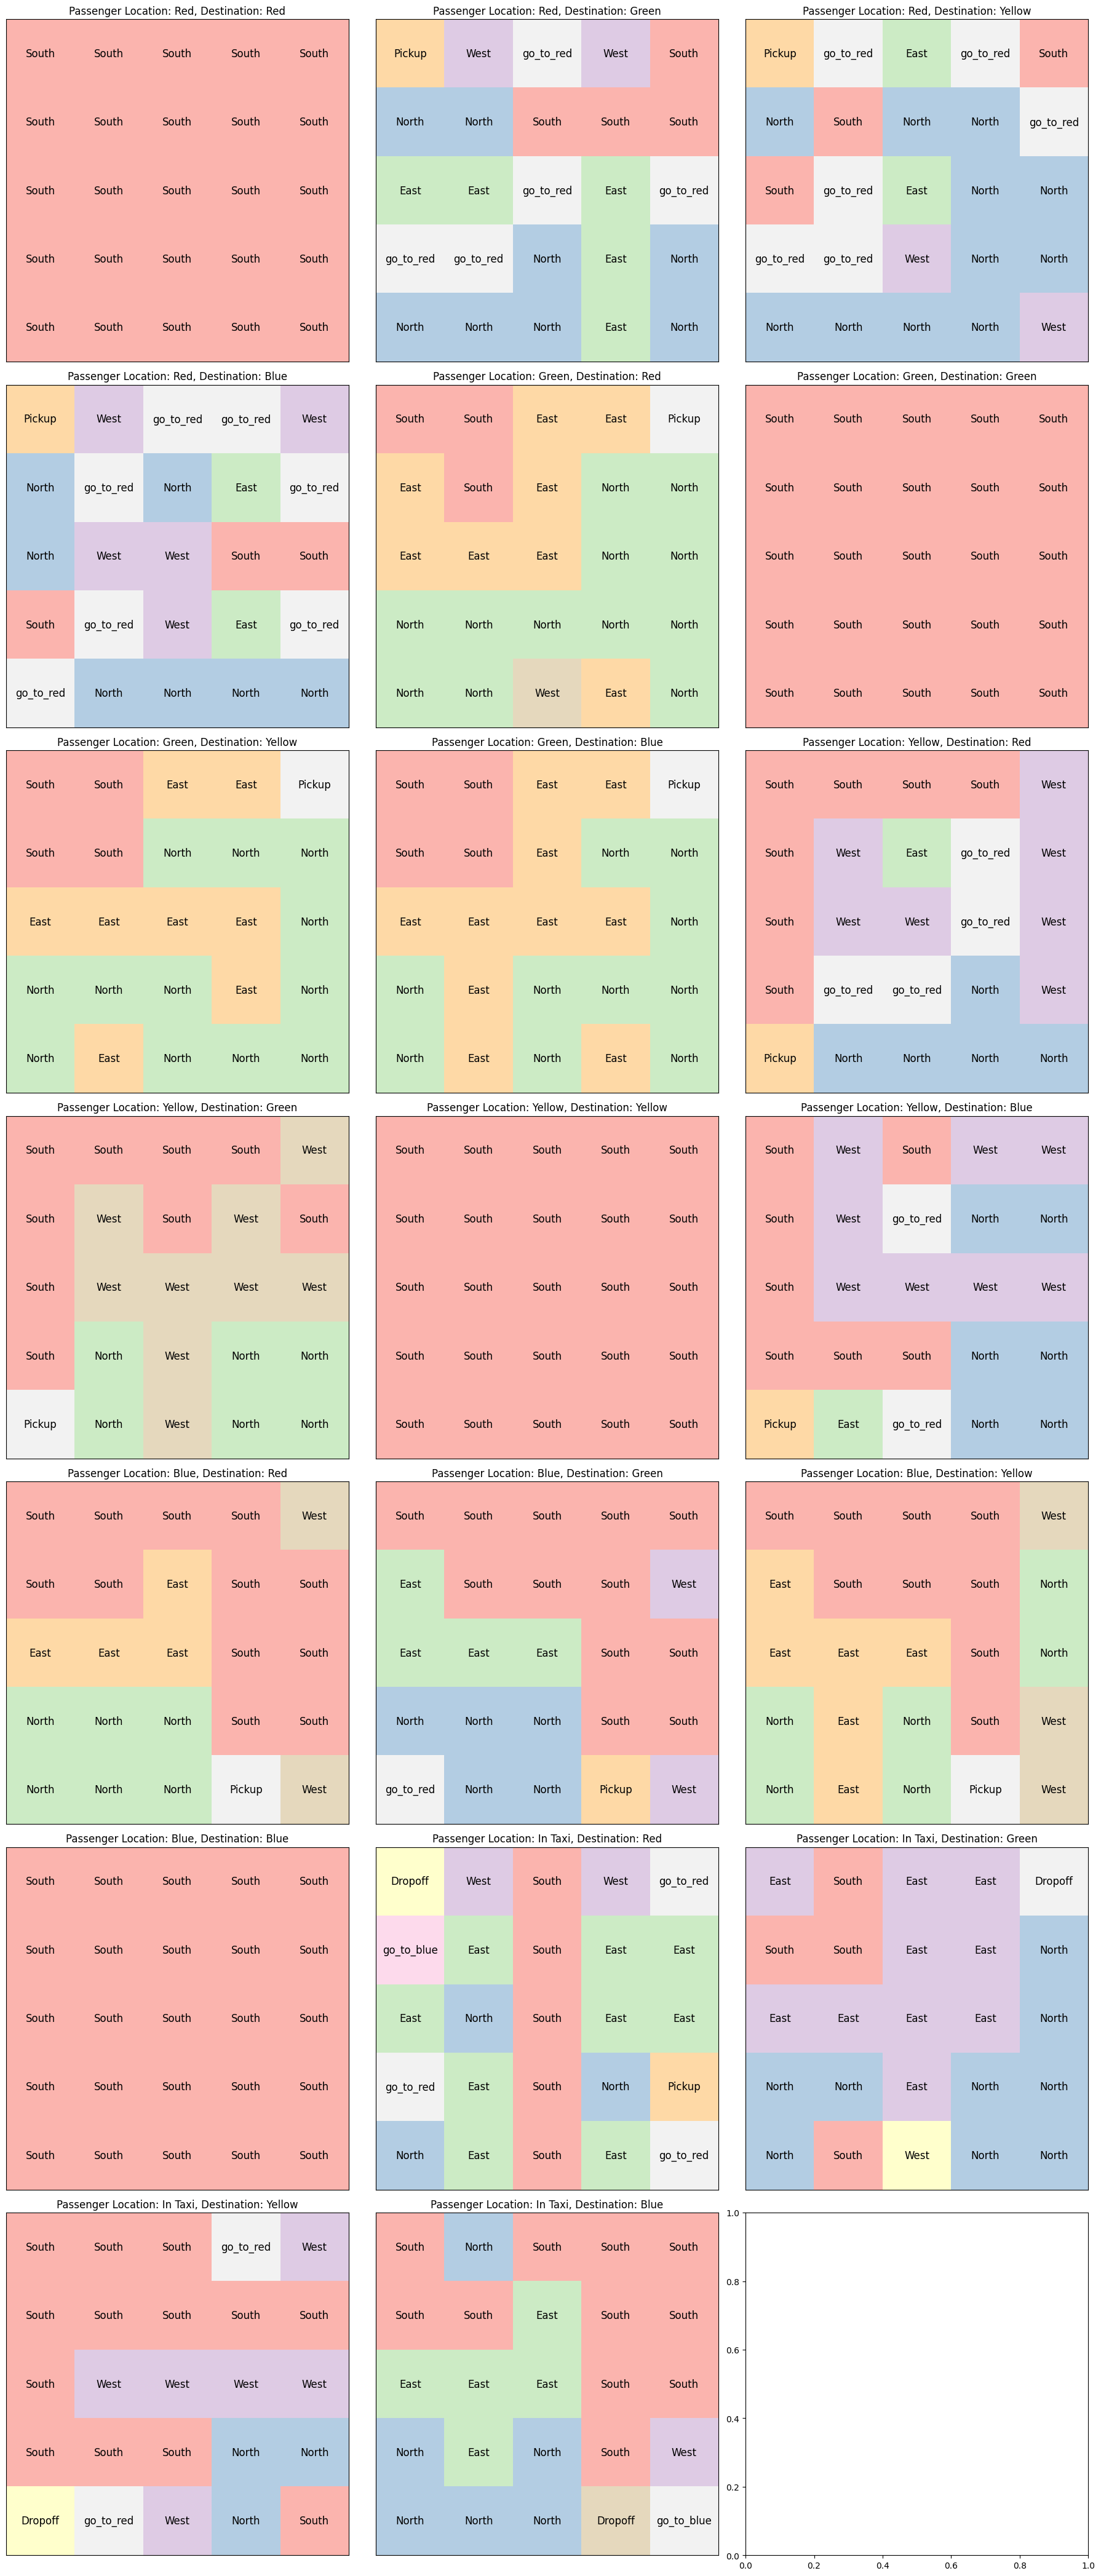

In [585]:
analysis_q_values = {}
for i in range(5):
    for j in range(4):
        analysis_q_values[(i,j)] = np.zeros((5,5))

for state in range(env.observation_space.n):
    taxi_row, taxi_col, pass_loc, dest_loc = decode_state(state)
    analysis_q_values[(pass_loc,dest_loc)][taxi_row, taxi_col] = np.argmax(q_values[state])

passenger_map = {
    0: "Red",
    1: "Green",
    2: "Yellow",
    3: "Blue",
    4: "In Taxi"
}
destination_map = {
    0: "Red",
    1: "Green",
    2: "Yellow",
    3: "Blue",
}

policy_titles = [
    f"Passenger Location: {passenger_map[pass_loc]}, Destination: {destination_map[dest_loc]}"
    for (pass_loc, dest_loc) in analysis_q_values.keys()
]
policies = [analysis_q_values[(pass_loc, dest_loc)] for (pass_loc, dest_loc) in analysis_q_values.keys()]
option_markers = {
    i : f"{option.name}" for i,  option in enumerate(possible_options)
}
visualize_options_policies(env, policies, policy_titles, symbol_map=option_markers)

### Defining the options in different way

In [ ]:
class Option:
    def __init__(self, initiation_set, policy, termination_condition, q_values, name=None):
        self.initiation_set = initiation_set
        self.policy = policy
        self.termination_condition = termination_condition
        self.name = name if name else "UnnamedOption"
        self.q_value = q_values

    def can_initiate(self, state):
        return self.initiation_set(state)

    def select_action(self, state):
        return int(self.policy(state, self.q_value))  # force scalar int

    def should_terminate(self, state):
        return self.termination_condition(state)

    def __repr__(self):
        return f"Option: {self.name}"


def epsilon_greedy_policy(state, q_values, epsilon=0.1):
    if np.random.rand() < epsilon:
        return int(np.random.choice(q_values.shape[1]))
    else:
        return int(np.argmax(q_values[state]))




In [443]:
def epsilon_greedy(state, q_values):
    if epsilon < np.random.rand():
        return int(np.random.choice(range(len(q_values[state]))))
    else:
        return int(np.argmax(q_values[state]))

In [558]:
from tqdm import tqdm

num_episodes = 5000
epsilon = 1
epsilon_decay = 0.9
gamma = 0.9
learning_rate = 0.01

# Define primitive options
possible_options = [
    Option(
        initiation_set=lambda state: True,
        policy=lambda state, q, act=action: act,
        termination_condition=lambda state: True,
        name=action_map[action],
        q_values=np.zeros((env.observation_space.n, env.action_space.n))
    )
    for action in range(env.action_space.n)
]

# Define predefined options
target_loc = {
    'go_to_green': (0, 4),
    'go_to_blue': (4, 3),
    'go_to_yellow': (4, 0),
    'go_to_red': (0, 0)
}

for option_name, policy_map in predefined_policies.items():
    target = target_loc[option_name]
    possible_options.append(
        Option(
            initiation_set=lambda state, tgt=target: decode_state(state)[:2] != tgt,
            policy=lambda state, q_values: epsilon_greedy_policy(state, q_values, epsilon),
            termination_condition=lambda state, tgt=target: decode_state(state)[:2] == tgt,
            name=option_name,
            q_values=np.random.uniform(-0.01,0.01,(env.observation_space.n, env.action_space.n))
        )
    )



q_values = np.random.uniform(-0.01,0.01,(env.observation_space.n, len(possible_options)))
reward_log = []

for episode in tqdm(range(num_episodes)):
    state, _ = env.reset()
    done = False
    episode_reward = 0

    while not done:
        feasible_options = [i for i, opt in enumerate(possible_options) if opt.can_initiate(state)]

        if not feasible_options:
            break

        if np.random.rand() < epsilon:
            option_idx = np.random.choice(feasible_options)
        else:
            option_idx = max(feasible_options, key=lambda i: q_values[state, i])

        option = possible_options[option_idx]
        initial_state = state
        cumulative_reward = 0
        discount = 1.0
        option_terminated = False

        while not option_terminated:
            action = option.select_action(state)
            # print(action)
            next_state, reward, terminated, truncated, info = env.step(action)

            # Intra-option Q update
            option.q_value[state, action] += learning_rate * (
                reward + gamma * np.max(option.q_value[next_state]*info['action_mask']) - option.q_value[state, action]
            )

            cumulative_reward += discount * reward
            discount *= gamma

            done = terminated or truncated
            option_terminated = option.should_terminate(next_state) or done
            state = next_state

        # Update Q for the selected option
        option_mask = [
            1 if opt.can_initiate(initial_state) else 0 for opt in possible_options
        ]

        q_values[initial_state, option_idx] += learning_rate * (
            cumulative_reward + gamma * np.max(q_values[state] * option_mask) - q_values[initial_state, option_idx]
        )
        # Update epsilon
        epsilon = max(0.01, epsilon * epsilon_decay)

        episode_reward += cumulative_reward

    reward_log.append(episode_reward)


100%|██████████| 5000/5000 [00:46<00:00, 108.02it/s]


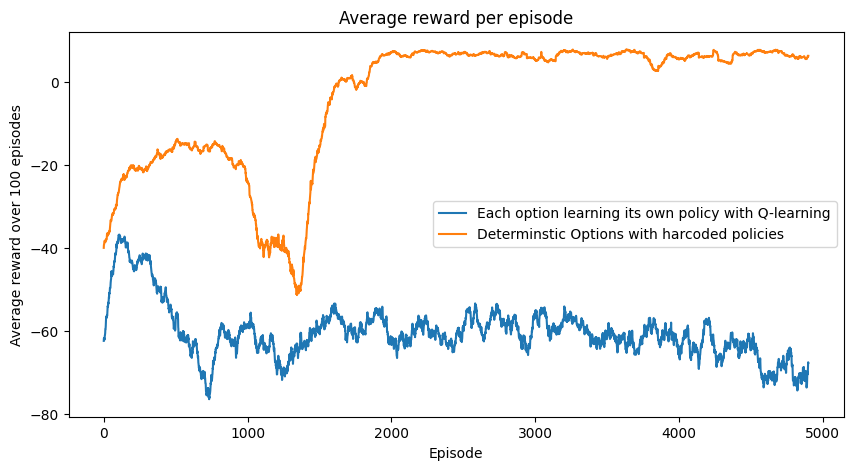

In [559]:
# reward_over_runs = np.array(reward_over_runs)
plt.figure(figsize=(10, 5))
plt.plot(np.convolve(reward_log, np.ones(100)/100, mode='valid'), label = 'Each option learning its own policy with Q-learning')
plt.plot(np.convolve(rewards, np.ones(100)/100, mode='valid'),label = 'Determinstic Options with harcoded policies')
plt.title("Average reward per episode")
plt.xlabel("Episode")
plt.ylabel("Average reward over 100 episodes")
plt.legend()
plt.show()

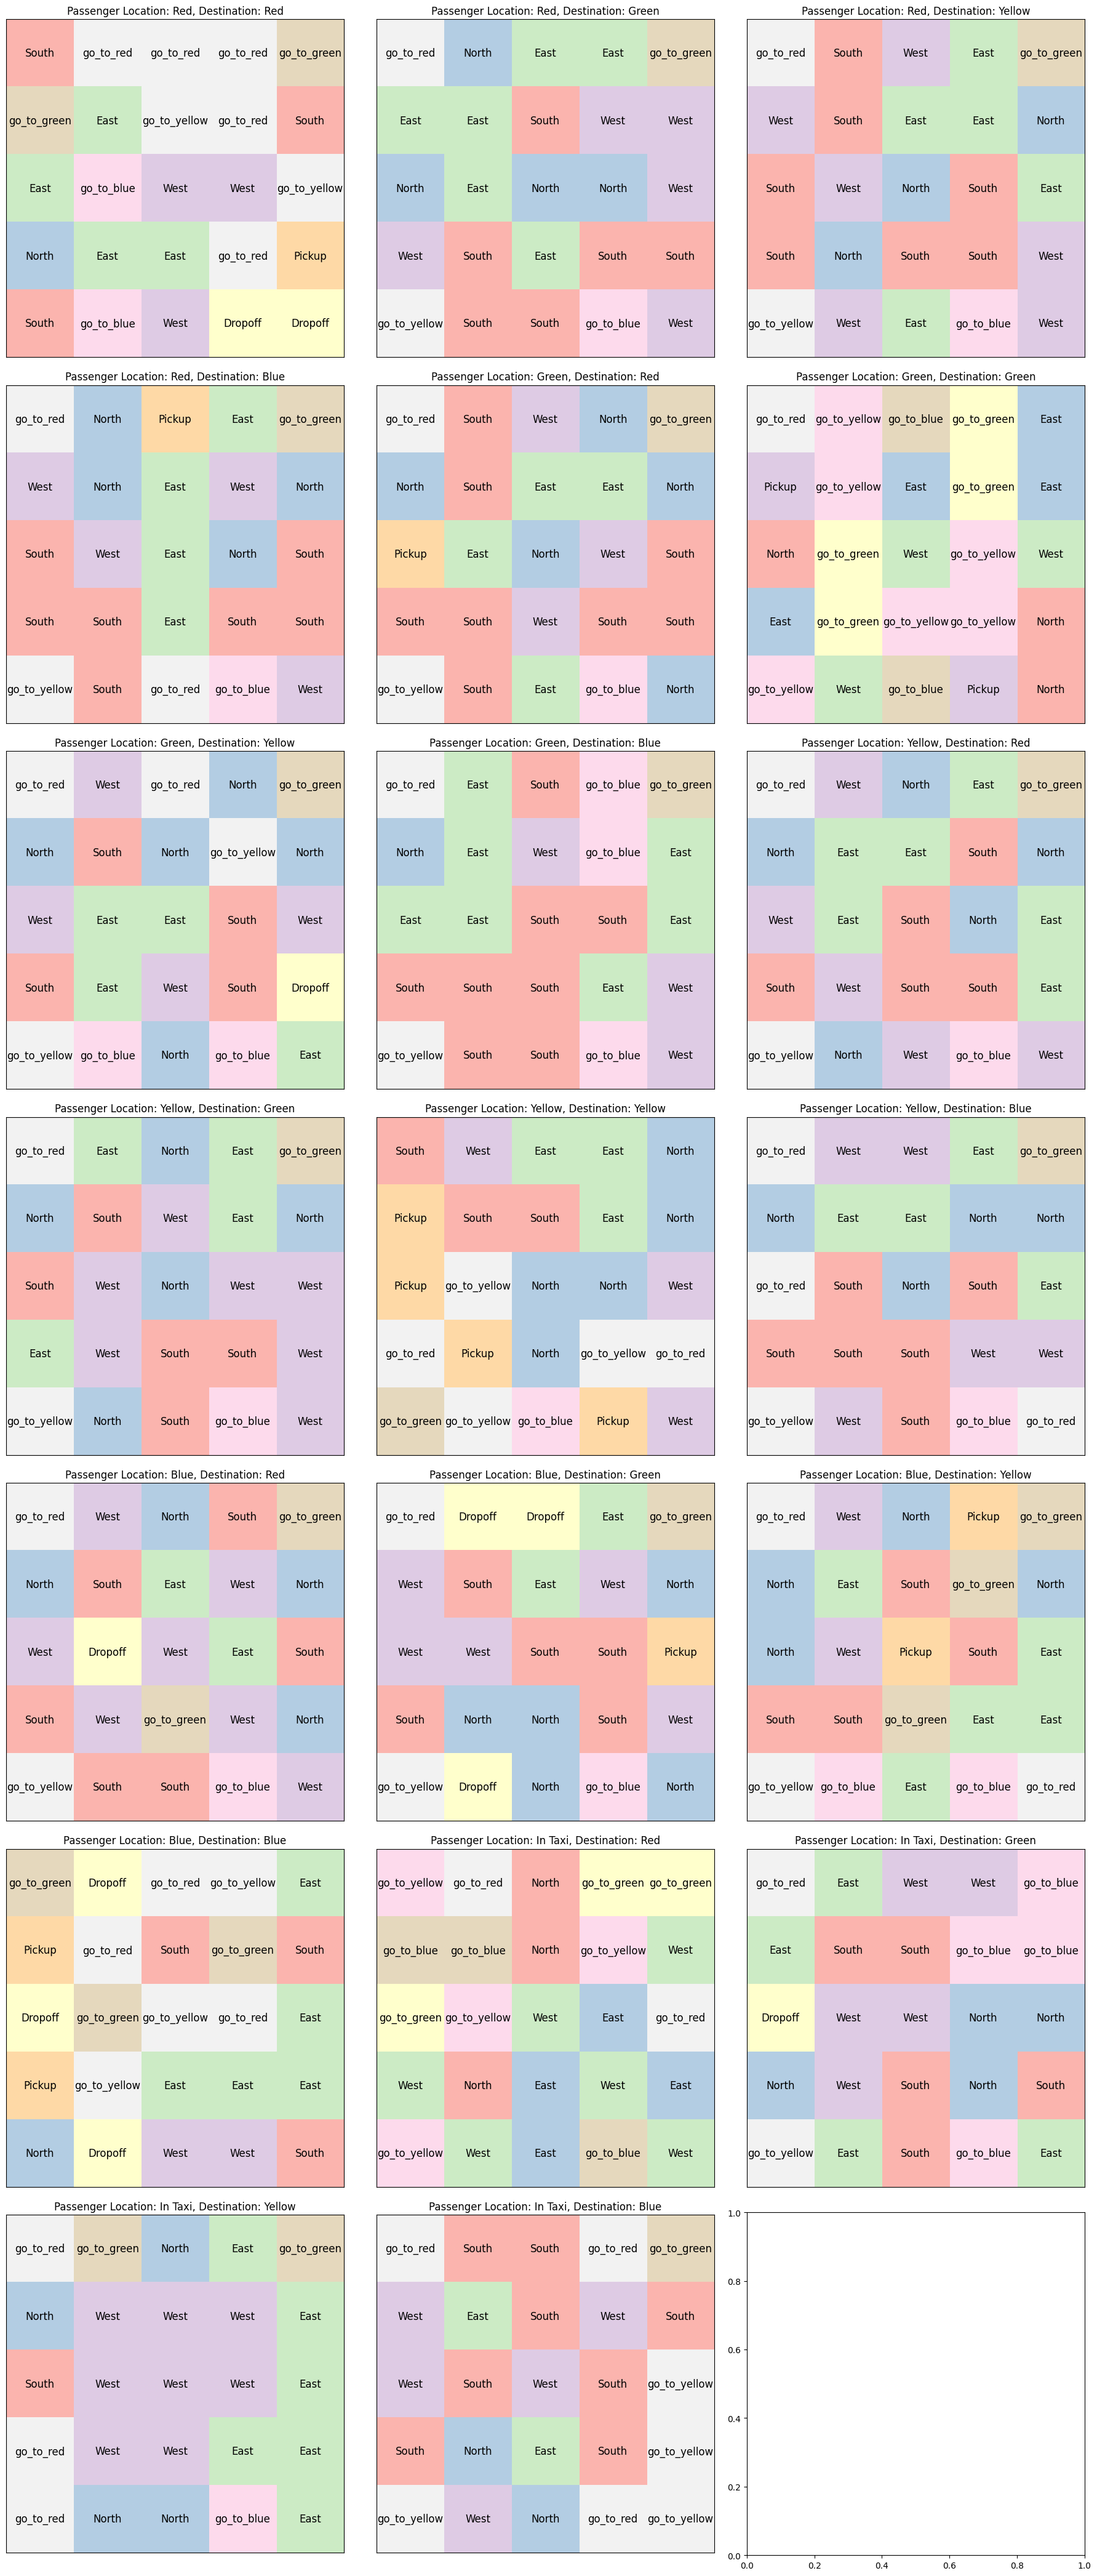

In [561]:
analysis_q_values = {}
for i in range(5):
    for j in range(4):
        analysis_q_values[(i,j)] = np.zeros((5,5))

for state in range(env.observation_space.n):
    taxi_row, taxi_col, pass_loc, dest_loc = decode_state(state)
    analysis_q_values[(pass_loc,dest_loc)][taxi_row, taxi_col] = np.argmax(q_values[state])

passenger_map = {
    0: "Red",
    1: "Green",
    2: "Yellow",
    3: "Blue",
    4: "In Taxi"
}
destination_map = {
    0: "Red",
    1: "Green",
    2: "Yellow",
    3: "Blue",
}

policy_titles = [
    f"Passenger Location: {passenger_map[pass_loc]}, Destination: {destination_map[dest_loc]}"
    for (pass_loc, dest_loc) in analysis_q_values.keys()
]
policies = [analysis_q_values[(pass_loc, dest_loc)] for (pass_loc, dest_loc) in analysis_q_values.keys()]
option_markers = {
    i : f"{option.name}" for i,  option in enumerate(possible_options)
}
visualize_options_policies(env, policies, policy_titles, symbol_map=option_markers)

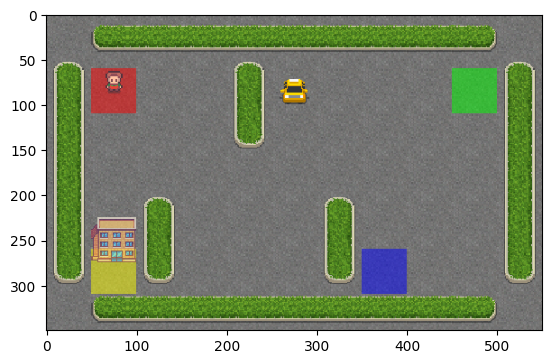

In [560]:
env.reset()
plt.imshow(env.render())    